In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import warnings
warnings.filterwarnings('ignore')

In [2]:
sick = pd.read_csv("sickfoot_f.csv")
normal = pd.read_csv("normalfoot_f.csv")

print("SICK columns:\n", sick.columns)
print("\nNORMAL columns:\n", normal.columns)


SICK columns:
 Index(['Temp1', 'Temp2', 'Temp3', 'Temp4', 'Temp5', 'BigF_T', 'Side_T',
       'Center_T', 'Pres1', 'Pres2', 'Pres3', 'Pres4', 'Pres5', 'BigF_P',
       'Side_P', 'Center_P', 'Label'],
      dtype='object')

NORMAL columns:
 Index(['Temp1', 'Temp2', 'Temp3', 'Temp4', 'Temp5', 'BigF_T', 'Side_T',
       'Center_T', 'Pres1', 'Pres2', 'Pres3', 'Pres4', 'Pres5', 'BigF_P',
       'Side_P', 'Center_P', 'Label'],
      dtype='object')


In [3]:
df = pd.concat([sick, normal], axis=0)

numeric_cols = df.columns[:-1]  # exclude Label

variances = df[numeric_cols].var().sort_values(ascending=False)
print(variances)


Pres4       6.211925e+07
Pres3       5.113727e+07
Pres5       4.969275e+07
Pres2       4.807685e+07
Pres1       3.906233e+07
Center_P    3.609738e+07
BigF_P      3.255827e+07
Side_P      8.019320e+06
Temp4       4.382052e+03
BigF_T      2.234780e+03
Temp5       1.753212e+02
Temp3       3.122957e+01
Center_T    1.764375e+01
Temp2       1.622644e+01
Temp1       1.204566e+01
Side_T      9.579591e+00
dtype: float64


In [4]:
df.drop(columns=['Temp1'], inplace=True)
df.drop(columns=['Temp3'], inplace=True)
df.drop(columns=['Temp4'], inplace=True)
df.drop(columns=['Pres1'], inplace=True)
df.drop(columns=['Pres3'], inplace=True)
df.drop(columns=['Pres4'], inplace=True)


In [5]:
df

,Temp2,Temp5,BigF_T,Side_T,Center_T,Pres2,Pres5,BigF_P,Side_P,Center_P,Label
0,23.670404,23.860387,23.166001,24.453311,23.809233,103.830583,141.792939,103.714719,176.566740,151.150779,1
1,23.698930,23.885617,23.181379,24.513571,23.842472,103.046557,146.415524,102.775794,178.830630,153.250787,1
2,23.727457,23.910847,23.196756,24.573830,23.875711,102.262532,151.038109,101.836870,181.094520,155.350795,1
3,23.756147,23.935938,23.212191,24.630898,23.907588,101.476076,155.507469,100.900611,183.307349,157.149321,1
4,23.784837,23.961030,23.227626,24.687967,23.939466,100.689620,159.976829,99.964353,185.520178,158.947848,1
...,...,...,...,...,...,...,...,...,...,...,...
58307,28.586327,28.930950,26.210462,28.867461,28.632921,620.609064,625.403906,70.404791,1015.218053,112.159831,0
58308,28.582795,28.929804,26.194717,28.873723,28.629304,579.066600,605.824349,54.183374,968.908033,92.988950,0
58309,28.579263,28.928658,26.178971,28.879985,28.625687,537.524135,586.244791,37.961958,922.598013,73.818069,0
58310,28.575731,28.927512,26.163226,28.886247,28.622070,495.981671,566.665233,21.740541,876.287994,54.647188,0


In [6]:
df.rename(columns={'Temp2': 'Temp1'}, inplace=True)
df.rename(columns={'Temp5': 'Temp2'}, inplace=True)
df.rename(columns={'Pres2': 'Pres1'}, inplace=True)
df.rename(columns={'Pres5': 'Pres2'}, inplace=True)

In [7]:
df

,Temp1,Temp2,BigF_T,Side_T,Center_T,Pres1,Pres2,BigF_P,Side_P,Center_P,Label
0,23.670404,23.860387,23.166001,24.453311,23.809233,103.830583,141.792939,103.714719,176.566740,151.150779,1
1,23.698930,23.885617,23.181379,24.513571,23.842472,103.046557,146.415524,102.775794,178.830630,153.250787,1
2,23.727457,23.910847,23.196756,24.573830,23.875711,102.262532,151.038109,101.836870,181.094520,155.350795,1
3,23.756147,23.935938,23.212191,24.630898,23.907588,101.476076,155.507469,100.900611,183.307349,157.149321,1
4,23.784837,23.961030,23.227626,24.687967,23.939466,100.689620,159.976829,99.964353,185.520178,158.947848,1
...,...,...,...,...,...,...,...,...,...,...,...
58307,28.586327,28.930950,26.210462,28.867461,28.632921,620.609064,625.403906,70.404791,1015.218053,112.159831,0
58308,28.582795,28.929804,26.194717,28.873723,28.629304,579.066600,605.824349,54.183374,968.908033,92.988950,0
58309,28.579263,28.928658,26.178971,28.879985,28.625687,537.524135,586.244791,37.961958,922.598013,73.818069,0
58310,28.575731,28.927512,26.163226,28.886247,28.622070,495.981671,566.665233,21.740541,876.287994,54.647188,0


In [8]:
(df < 0).sum()


Temp1       0
Temp2       0
BigF_T      0
Side_T      0
Center_T    0
Pres1       0
Pres2       0
BigF_P      0
Side_P      0
Center_P    0
Label       0
dtype: int64

In [9]:
df['Label'].value_counts()

Label
0    58312
1    24852
Name: count, dtype: int64

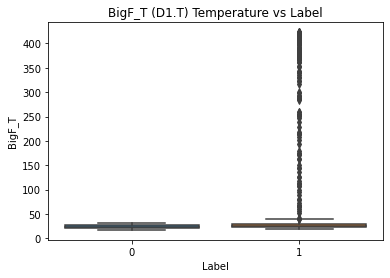

In [10]:
plt.figure(figsize=(6,4))
sns.boxplot(data=df, x='Label', y='BigF_T')
plt.title("BigF_T (D1.T) Temperature vs Label")
plt.show()

=== Comparison Table ===


,Normal_mean,Sick_mean,Mean_Difference,% Mean_Difference,Normal_min,Sick_min,Normal_max,Sick_max,Normal_std,Sick_std
BigF_T,23.893745,46.709362,22.815616,95.487819,17.132333,18.127311,31.782295,423.091022,3.508693,84.170748
Center_T,26.863988,28.261295,1.397307,5.201413,20.435776,4.038048,34.979304,86.913495,2.801438,6.265801
Side_T,26.108214,28.461472,2.353259,9.013480,20.726124,20.495730,31.768913,47.873181,2.451308,3.751694
Temp1,25.327732,28.066910,2.739178,10.814935,20.468561,18.957146,31.274306,96.569363,2.627898,5.730271
Temp2,25.776689,29.702208,3.925519,15.228949,20.335151,9.787708,31.783382,252.200000,2.606594,23.663448
BigF_P,1772.450745,6251.313712,4478.862967,252.693226,0.000000,0.000000,4087.767637,32396.417816,1523.872813,9457.278366
Center_P,2104.255865,6589.715130,4485.459266,213.161305,0.000000,0.000000,4002.481200,32301.232150,1590.447973,10037.710917
Side_P,2602.414563,3040.874036,438.459473,16.848179,0.000000,0.000000,4015.653102,32280.055178,1380.447654,4714.884765
Pres1,2630.484787,9164.409748,6533.924961,248.392425,0.000000,0.000000,4029.571044,32286.860282,1375.001658,11247.917716
Pres2,2660.693988,9424.692925,6763.998937,254.219349,0.000000,0.000000,4019.814109,34705.914857,1393.529370,11386.725448


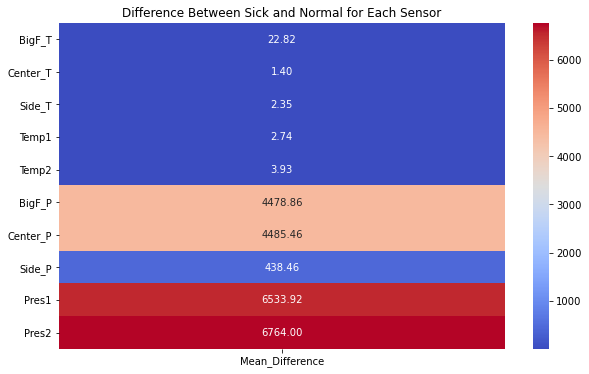

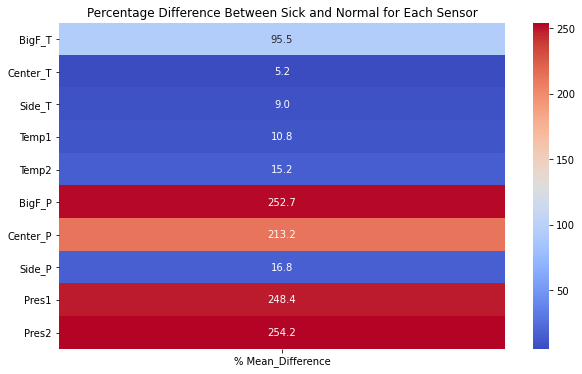

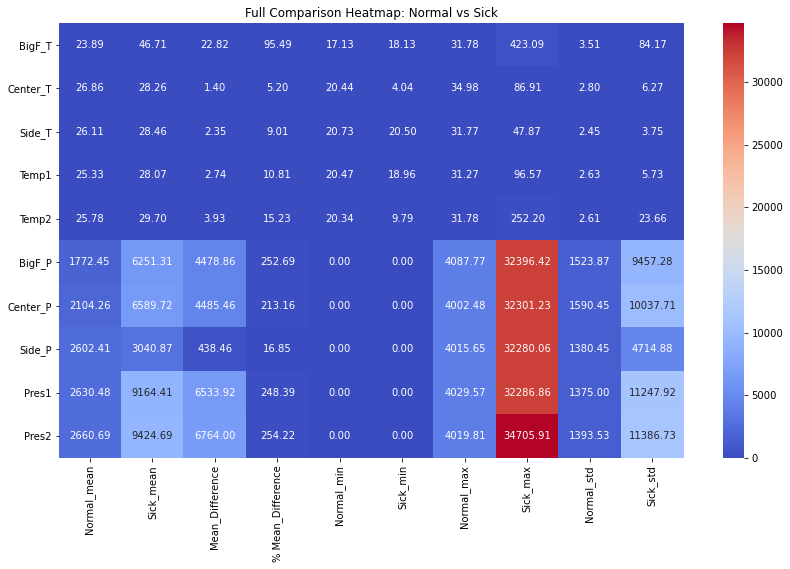

In [11]:
# ===========================
# 1) قائمة السنسورات اللي هنقارنها
# ===========================
sensor_cols = [
    'BigF_T','Center_T','Side_T','Temp1','Temp2',
    'BigF_P','Center_P','Side_P','Pres1','Pres2'
]

# ===========================
# 2) حساب إحصائيات Normal و Sick
# ===========================
normal_stats = df[df['Label'] == 0][sensor_cols].agg(['mean','std','min','max']).T
sick_stats   = df[df['Label'] == 1][sensor_cols].agg(['mean','std','min','max']).T

# ===========================
# 3) جدول المقارنة النهائي
# ===========================
comparison_df = pd.DataFrame({
    'Normal_mean': normal_stats['mean'],
    'Sick_mean': sick_stats['mean'],
    'Mean_Difference': sick_stats['mean'] - normal_stats['mean'],
    '% Mean_Difference': ((sick_stats['mean'] - normal_stats['mean']) / normal_stats['mean']) * 100,
    'Normal_min': normal_stats['min'],
    'Sick_min': sick_stats['min'],
    'Normal_max': normal_stats['max'],
    'Sick_max': sick_stats['max'],
    'Normal_std': normal_stats['std'],
    'Sick_std': sick_stats['std']
})

# نعرض الجدول
print("=== Comparison Table ===")
display(comparison_df)

# ===========================
# 4) HEATMAP 1 — Mean Difference
# ===========================
plt.figure(figsize=(10,6))
sns.heatmap(comparison_df[['Mean_Difference']], annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Difference Between Sick and Normal for Each Sensor")
plt.show()

# ===========================
# 5) HEATMAP 2 — Percentage Difference
# ===========================
plt.figure(figsize=(10,6))
sns.heatmap(comparison_df[['% Mean_Difference']], annot=True, cmap='coolwarm', fmt=".1f")
plt.title("Percentage Difference Between Sick and Normal for Each Sensor")
plt.show()

# ===========================
# 6) HEATMAP 3 — Full Comparison
# ===========================
plt.figure(figsize=(14,8))
sns.heatmap(comparison_df, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Full Comparison Heatmap: Normal vs Sick")
plt.show()


In [12]:
pressure_cols = ['BigF_P','Center_P','Side_P','Pres1','Pres2']
df = df[(df[pressure_cols] <= 4095).all(axis=1)].reset_index(drop=True)

In [13]:
temp_cols = ['BigF_T','Center_T','Side_T','Temp1','Temp2']
df = df[(df[temp_cols] >= 20).all(axis=1) & (df[temp_cols] <= 40).all(axis=1)].reset_index(drop=True)

In [14]:
df[pressure_cols] = df[pressure_cols].clip(lower=0, upper=4095)
df[temp_cols] = df[temp_cols].clip(lower=20, upper=40)

=== Comparison Table ===


,Normal_mean,Sick_mean,Mean_Difference,% Mean_Difference,Normal_min,Sick_min,Normal_max,Sick_max,Normal_std,Sick_std
BigF_T,24.768706,25.374294,0.605588,2.444974,20.000872,20.194011,31.782295,31.977052,2.996770,2.879940
Center_T,27.568492,28.576686,1.008194,3.657051,21.918954,22.056479,34.979304,32.940266,2.369354,2.584498
Side_T,26.751173,27.849105,1.097932,4.104239,20.726124,21.507708,31.768913,32.144610,2.024782,2.133406
Temp1,25.977917,27.339039,1.361122,5.239535,21.088889,20.167782,31.274306,32.601897,2.261423,2.655873
Temp2,26.426875,27.512746,1.085871,4.108965,20.335151,20.699753,31.783382,31.410496,2.233043,2.615419
BigF_P,1838.978677,1953.552423,114.573746,6.230292,0.000000,0.000000,4087.767637,4006.416722,1500.091919,1608.598689
Center_P,1968.597709,1605.112282,-363.485427,-18.464180,0.000000,0.000000,4002.481200,4037.059417,1589.105310,1715.073817
Side_P,2663.159052,2750.242944,87.083892,3.269947,0.000000,0.000000,4015.653102,4034.788513,1386.547554,1591.024480
Pres1,2624.649754,2792.579838,167.930085,6.398190,0.000000,0.000000,4029.571044,4061.771815,1378.179182,1403.360766
Pres2,2809.767574,2920.070115,110.302542,3.925682,0.000000,0.000000,4019.814109,4037.510550,1340.179517,1514.175680


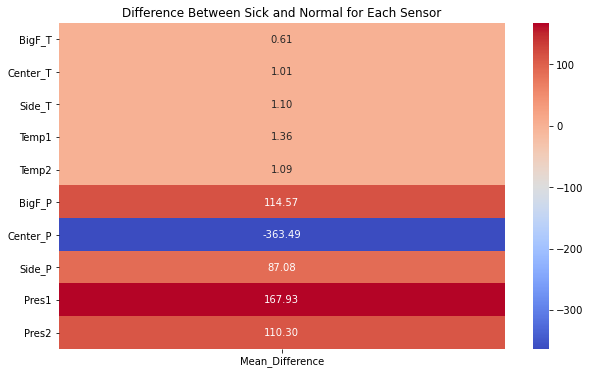

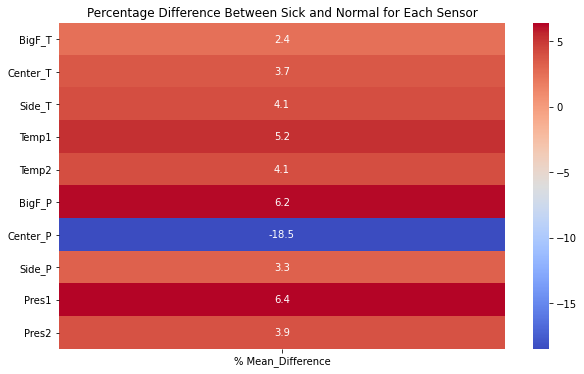

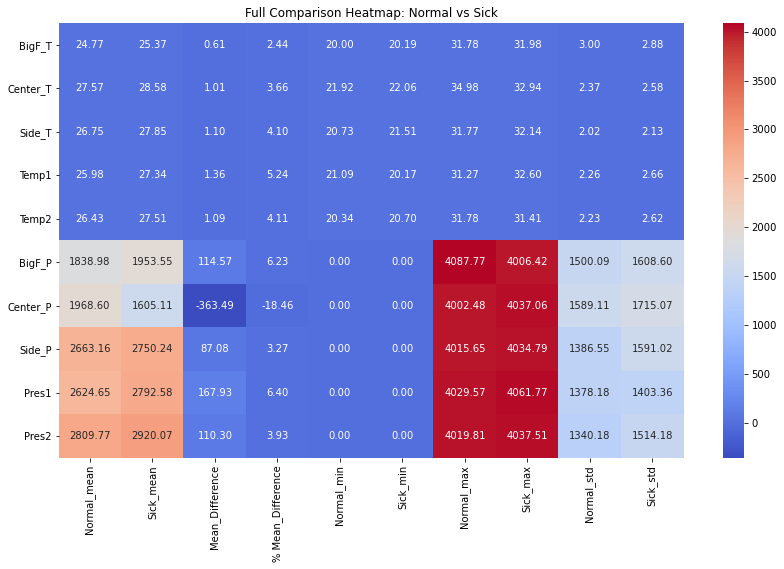

In [15]:
# ===========================
# 1) قائمة السنسورات اللي هنقارنها
# ===========================
sensor_cols = [
    'BigF_T','Center_T','Side_T','Temp1','Temp2',
    'BigF_P','Center_P','Side_P','Pres1','Pres2'
]

# ===========================
# 2) حساب إحصائيات Normal و Sick
# ===========================
normal_stats = df[df['Label'] == 0][sensor_cols].agg(['mean','std','min','max']).T
sick_stats   = df[df['Label'] == 1][sensor_cols].agg(['mean','std','min','max']).T

# ===========================
# 3) جدول المقارنة النهائي
# ===========================
comparison_df = pd.DataFrame({
    'Normal_mean': normal_stats['mean'],
    'Sick_mean': sick_stats['mean'],
    'Mean_Difference': sick_stats['mean'] - normal_stats['mean'],
    '% Mean_Difference': ((sick_stats['mean'] - normal_stats['mean']) / normal_stats['mean']) * 100,
    'Normal_min': normal_stats['min'],
    'Sick_min': sick_stats['min'],
    'Normal_max': normal_stats['max'],
    'Sick_max': sick_stats['max'],
    'Normal_std': normal_stats['std'],
    'Sick_std': sick_stats['std']
})

# نعرض الجدول
print("=== Comparison Table ===")
display(comparison_df)

# ===========================
# 4) HEATMAP 1 — Mean Difference
# ===========================
plt.figure(figsize=(10,6))
sns.heatmap(comparison_df[['Mean_Difference']], annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Difference Between Sick and Normal for Each Sensor")
plt.show()

# ===========================
# 5) HEATMAP 2 — Percentage Difference
# ===========================
plt.figure(figsize=(10,6))
sns.heatmap(comparison_df[['% Mean_Difference']], annot=True, cmap='coolwarm', fmt=".1f")
plt.title("Percentage Difference Between Sick and Normal for Each Sensor")
plt.show()

# ===========================
# 6) HEATMAP 3 — Full Comparison
# ===========================
plt.figure(figsize=(14,8))
sns.heatmap(comparison_df, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Full Comparison Heatmap: Normal vs Sick")
plt.show()


In [16]:
normal = df[df['Label'] == 0]
sick   = df[df['Label'] == 1]


In [17]:
normal_balanced = normal.sample(25000, random_state=42)
def add_noise(df, std_factor=0.01):
    noisy = df.copy()
    for col in df.columns:
        if col != "Label":
            noise = np.random.normal(0, df[col].std() * std_factor, size=len(df))
            noisy[col] = df[col] + noise
    return noisy

extra_needed = 25000 - len(sick)
sick_extra = add_noise(sick.sample(extra_needed, replace=True))
sick_balanced = pd.concat([sick, sick_extra], ignore_index=True)

# 5) دمج
df_balanced = pd.concat([normal_balanced, sick_balanced], ignore_index=True)

# 6) Shuffle
df_balanced = df_balanced.sample(frac=1, random_state=42).reset_index(drop=True)


In [18]:
df_balanced

,Temp1,Temp2,BigF_T,Side_T,Center_T,Pres1,Pres2,BigF_P,Side_P,Center_P,Label
0,29.729725,30.378805,24.012389,28.677395,29.540082,3161.488387,3969.829342,0.000000,3985.413411,3908.228407,1
1,24.280256,24.453490,24.873637,25.579346,27.642262,3865.776205,3928.751840,3294.551072,3098.599096,3452.109899,0
2,23.494853,24.799212,20.851133,24.412144,23.864287,3969.319228,3981.295692,0.000000,3874.745052,130.296428,0
3,26.049517,29.195709,24.033503,29.287696,30.094590,625.676252,856.690799,0.000000,0.000000,0.000000,0
4,27.578530,26.837364,27.987641,27.297500,31.012442,3391.526653,1331.799659,3794.144677,0.000000,12.797967,1
...,...,...,...,...,...,...,...,...,...,...,...
49995,23.544753,24.688135,20.784074,24.805663,25.681122,3684.466927,2282.419301,0.000000,947.691389,1730.137409,0
49996,22.252404,21.528890,20.584349,22.755095,22.600798,3909.859224,3844.132603,1845.657580,3875.319711,28.131628,1
49997,26.811163,27.783720,25.769328,28.158999,31.021490,3705.478962,3930.536100,3572.302069,3925.939883,3925.725508,1
49998,26.856044,27.005108,25.033738,28.148353,29.112985,62.500403,3971.158464,2772.257545,3957.961628,0.000000,0


In [19]:
df_balanced['Label'].value_counts()

Label
1    25000
0    25000
Name: count, dtype: int64

In [20]:
print("Duplicated rows:", df_balanced.duplicated().sum())

Duplicated rows: 0


In [21]:
#df_balanced.to_csv("ulcer.csv", index=False)